In [167]:
import os
import pandas as pd
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC

In [168]:
output_folder = "/mnt/d/lding/DSI/promega/metabolite_classifier_results"
methodstr = "LogisticRegression_SMOTE"
datestr = "20250716"
test_ID = "organoid_surveys_aggregated_" + methodstr + "_" + datestr
output_folder = os.path.join(output_folder, test_ID)
os.makedirs(output_folder, exist_ok=True)

In [169]:
survey_json_path = "/mnt/d/lding/DSI/promega/2025-promega-mini-test/surveys/labeled_organoid_mapping_for_classification.json"

In [170]:
all_labels_json_path = "/mnt/d/lding/DSI/promega/2025-promega-mini-test/surveys/organoid_surveys_aggregated.json"

In [171]:
meta_json_path = "/mnt/d/lding/DSI/promega/metabolite_data/metabolite_map.json"

In [172]:
with open(survey_json_path, "r") as f:
    survey_json = json.load(f)

with open(all_labels_json_path, "r") as f:
    all_survey_json = json.load(f)

with open(meta_json_path, "r") as f:
    meta_json = json.load(f)

In [173]:
eval_rows = []

for organoid_id, contents in all_survey_json.items():
    for entry in contents.get("evaluations", []):
        row = entry.copy()
        row["organoid_id"] = organoid_id  # Add organoid identifier
        eval_rows.append(row)

evaluations_df = pd.DataFrame(eval_rows)

In [174]:
# Count evaluations per image_id
eval_counts = (
    evaluations_df.groupby(["image_id", "evaluation"])
    .size()
    .unstack(fill_value=0)  # converts to wide format with 0 for missing
    .reset_index()
)

In [175]:
eval_counts["fully_agreed_consensus"] = eval_counts.apply(
    lambda row: "Acceptable"
    if row.get("Acceptable", 0) > 4
    else "Not Acceptable"
    if row.get("Not Acceptable", 0) > 4
    else "Not fully agreed",
    axis=1,
)


eval_counts["majority_agreed_consensus"] = eval_counts.apply(
    lambda row: "Acceptable"
    if row.get("Acceptable", 0) >= 4
    else "Not Acceptable"
    if row.get("Not Acceptable", 0) >= 4
    else "Not majorly agreed",
    axis=1,
)

In [176]:
eval_counts

evaluation,image_id,Acceptable,Not Acceptable,fully_agreed_consensus,majority_agreed_consensus
0,Ba1 96_1 Dy28 A2,5,0,Acceptable,Acceptable
1,Ba1 96_1 Dy28 A8,1,4,Not fully agreed,Not Acceptable
2,Ba1 96_1 Dy28 D4,2,3,Not fully agreed,Not majorly agreed
3,Ba1 96_1 Dy28 E10,1,4,Not fully agreed,Not Acceptable
4,Ba1 96_1 Dy28 F12,5,0,Acceptable,Acceptable
...,...,...,...,...,...
416,Ba4 96_1 Dy30 H5,0,5,Not Acceptable,Not Acceptable
417,Ba4 96_1 Dy30 H6,5,0,Acceptable,Acceptable
418,Ba4 96_1 Dy30 H7,1,4,Not fully agreed,Not Acceptable
419,Ba4 96_1 Dy30 H8,1,4,Not fully agreed,Not Acceptable


In [177]:
fully_agreed_eval = eval_counts[
    eval_counts["fully_agreed_consensus"] != "Not fully agreed"
]

In [178]:
major_agreed_eval = eval_counts[
    eval_counts["majority_agreed_consensus"] != "Not majorly agreed"
]

In [179]:
# Convert to DataFrame
survey_df = pd.DataFrame.from_dict(survey_json, orient="index").reset_index()
survey_df.columns = ["name", "img_path", "seg_map_path", "label"]

In [180]:
flattened_list = []

for sample_id, assays in meta_json.items():
    flattened = {}
    for assay_name, assay_data in assays.items():
        for key, value in assay_data.items():
            col_name = f"{assay_name}_{key}"
            flattened[col_name] = value
    flattened["sample_id"] = sample_id  # add at end
    flattened_list.append(flattened)

# Create DataFrame from all rows
meta_df = pd.DataFrame(flattened_list)

In [205]:
meta_df

,GlucoseGlo_concentration_uM,GlucoseGlo_initial_concentration,GlucoseGlo_is_outlier,GlucoseGlo_well_384,GlutamateGlo_concentration_uM,GlutamateGlo_initial_concentration,GlutamateGlo_is_outlier,GlutamateGlo_well_384,MalateGlo_concentration_uM,MalateGlo_initial_concentration,...,BCAAGlo_well_384,LactateGlo_concentration_uM,LactateGlo_initial_concentration,LactateGlo_is_outlier,LactateGlo_well_384,PyruvateGlo_concentration_uM,PyruvateGlo_initial_concentration,PyruvateGlo_is_outlier,PyruvateGlo_well_384,sample_id
0,9.745,19490.540,False,B2,2.303,230.285,False,A2,0.184,3.679,...,B2,7.711,3084.523,False,B1,4.045,404.473,False,A2,BA1 96_1 Dy03 A1
1,9.470,18940.354,False,B4,2.135,213.528,False,A4,0.165,3.309,...,B4,6.803,2721.352,False,B3,3.898,389.758,False,A4,BA1 96_1 Dy03 A2
2,8.861,17722.357,False,B6,2.170,217.031,False,A6,0.170,3.405,...,B6,6.688,2675.235,False,B5,3.074,307.354,False,A6,BA1 96_1 Dy03 A3
3,8.330,16659.930,False,B8,2.141,214.137,False,A8,0.151,3.018,...,B8,6.515,2606.059,False,B7,4.628,462.842,False,A8,BA1 96_1 Dy03 A4
4,8.618,17236.676,False,B10,2.173,217.336,False,A10,0.139,2.786,...,B10,6.736,2694.450,False,B9,4.658,465.785,False,A10,BA1 96_1 Dy03 A5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3163,10.088,20176.350,False,P16,0.175,17.525,False,O16,0.048,0.954,...,P16,15.515,6206.019,False,P15,2.612,261.218,False,O16,BA2 96_2 Dy30 H8
3164,11.966,23932.102,False,P18,0.182,18.195,False,O18,0.029,0.578,...,P18,14.543,5817.331,False,P17,3.174,317.425,False,O18,BA2 96_2 Dy30 H9
3165,9.584,19168.313,False,P20,0.136,13.591,False,O20,0.093,1.869,...,P20,20.206,8082.257,False,P19,3.378,337.838,False,O20,BA2 96_2 Dy30 H10
3166,10.365,20729.145,False,P22,0.083,8.288,False,O22,0.016,0.317,...,P22,12.241,4896.467,False,P21,3.145,314.467,False,O22,BA2 96_2 Dy30 H11


In [181]:
meta_df.columns

Index(['GlucoseGlo_concentration_uM', 'GlucoseGlo_initial_concentration',
       'GlucoseGlo_is_outlier', 'GlucoseGlo_well_384',
       'GlutamateGlo_concentration_uM', 'GlutamateGlo_initial_concentration',
       'GlutamateGlo_is_outlier', 'GlutamateGlo_well_384',
       'MalateGlo_concentration_uM', 'MalateGlo_initial_concentration',
       'MalateGlo_is_outlier', 'MalateGlo_well_384',
       'BCAAGlo_concentration_uM', 'BCAAGlo_initial_concentration',
       'BCAAGlo_is_outlier', 'BCAAGlo_well_384', 'LactateGlo_concentration_uM',
       'LactateGlo_initial_concentration', 'LactateGlo_is_outlier',
       'LactateGlo_well_384', 'PyruvateGlo_concentration_uM',
       'PyruvateGlo_initial_concentration', 'PyruvateGlo_is_outlier',
       'PyruvateGlo_well_384', 'sample_id'],
      dtype='object')

In [182]:
select_meta_df = meta_df[
    [
        "sample_id",
        "GlucoseGlo_concentration_uM",
        "GlutamateGlo_concentration_uM",
        "MalateGlo_concentration_uM",
        "BCAAGlo_concentration_uM",
        "LactateGlo_concentration_uM",
        "PyruvateGlo_concentration_uM",
    ]
]

In [211]:
select_meta_df[select_meta_df["sample_id"] == "BA1 96_1 DY30 A8"]

,sample_id,GlucoseGlo_concentration_uM,GlutamateGlo_concentration_uM,MalateGlo_concentration_uM,BCAAGlo_concentration_uM,LactateGlo_concentration_uM,PyruvateGlo_concentration_uM,ID-DY,DY
967,BA1 96_1 DY30 A8,12.801,0.306,0.287,5.702,15.952,1.938,BA1 96_1 A8,DY30


In [214]:
select_meta_df.iloc[963:972]

,sample_id,GlucoseGlo_concentration_uM,GlutamateGlo_concentration_uM,MalateGlo_concentration_uM,BCAAGlo_concentration_uM,LactateGlo_concentration_uM,PyruvateGlo_concentration_uM,ID-DY,DY
963,BA1 96_1 DY30 A4,13.065,0.194,0.250,6.008,15.478,2.082,BA1 96_1 A4,DY30
964,BA1 96_1 DY30 A5,13.311,0.225,0.169,5.913,12.521,1.625,BA1 96_1 A5,DY30
965,BA1 96_1 DY30 A6,12.195,0.192,0.310,5.904,20.228,1.801,BA1 96_1 A6,DY30
966,BA1 96_1 DY30 A7,11.973,0.170,0.160,5.309,15.384,1.737,BA1 96_1 A7,DY30
967,BA1 96_1 DY30 A8,12.801,0.306,0.287,5.702,15.952,1.938,BA1 96_1 A8,DY30
968,BA1 96_1 DY30 A9,14.500,0.226,0.186,6.316,17.600,0.674,BA1 96_1 A9,DY30
969,BA1 96_1 DY30 A10,11.278,0.192,0.376,5.083,24.932,1.557,BA1 96_1 A10,DY30
970,BA1 96_1 DY30 A11,12.505,0.207,0.219,5.765,20.092,1.689,BA1 96_1 A11,DY30
971,BA1 96_1 DY30 A12,12.005,0.222,0.457,5.673,32.747,2.399,BA1 96_1 A12,DY30


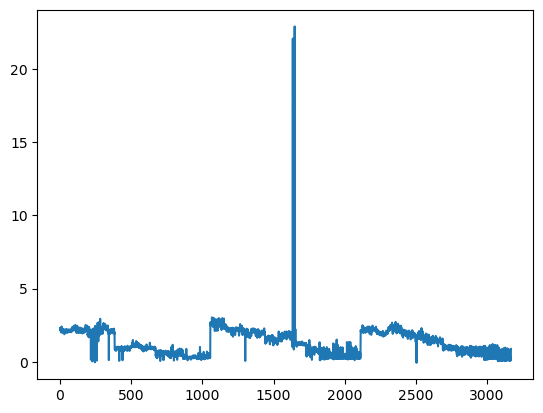

In [217]:
plt.plot(select_meta_df.GlutamateGlo_concentration_uM)

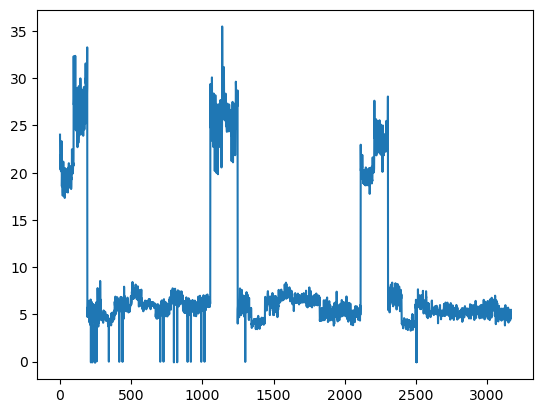

In [218]:
plt.plot(select_meta_df.BCAAGlo_concentration_uM)

In [183]:
def normalize_id(s):
    return s.strip().upper().replace("Ba", "BA").replace("Dy", "DY")


# Apply to both DataFrames
major_agreed_eval["image_id"] = major_agreed_eval["image_id"].apply(normalize_id)
select_meta_df["sample_id"] = select_meta_df["sample_id"].apply(normalize_id)

/home/ldin/anaconda3/envs/segmentation/lib/python3.7/site-packages/ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """
/home/ldin/anaconda3/envs/segmentation/lib/python3.7/site-packages/ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [184]:
select_meta_df

# Extract parts
parts = select_meta_df["sample_id"].str.extract(r"^(.*) (DY\d{2}) (.*)$")
parts.columns = ["prefix", "DY", "suffix"]

# Create new column: prefix + suffix
select_meta_df["ID-DY"] = parts["prefix"] + " " + parts["suffix"]
select_meta_df["DY"] = parts["DY"]

/home/ldin/anaconda3/envs/segmentation/lib/python3.7/site-packages/ipykernel_launcher.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/home/ldin/anaconda3/envs/segmentation/lib/python3.7/site-packages/ipykernel_launcher.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if __name__ == "__main__":


In [185]:
# Extract parts
parts = major_agreed_eval["image_id"].str.extract(r"^(.*) (DY\d{2}) (.*)$")
parts.columns = ["prefix", "DY", "suffix"]

# Create new column: prefix + suffix
major_agreed_eval["ID-DY"] = parts["prefix"] + " " + parts["suffix"]
major_agreed_eval["DY"] = parts["DY"]

/home/ldin/anaconda3/envs/segmentation/lib/python3.7/site-packages/ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/home/ldin/anaconda3/envs/segmentation/lib/python3.7/site-packages/ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  import sys


In [186]:
len(major_agreed_eval)

333

In [187]:
# Group by 'ID-DY' and collect unique DY values
dy_sets = major_agreed_eval.groupby("ID-DY")["DY"].unique()

# Filter for those that contain both 'DY28' and 'DY30'
dy28_30_ids = dy_sets[dy_sets.apply(lambda x: {"DY28", "DY30"}.issubset(set(x)))].index

# Filter the original DataFrame to include only those ID-DY values
result_df = major_agreed_eval[major_agreed_eval["ID-DY"].isin(dy28_30_ids)]

result_df.sort_values(by="ID-DY")

evaluation,image_id,Acceptable,Not Acceptable,fully_agreed_consensus,majority_agreed_consensus,ID-DY,DY
0,BA1 96_1 DY28 A2,5,0,Acceptable,Acceptable,BA1 96_1 A2,DY28
10,BA1 96_1 DY30 A2,4,1,Not fully agreed,Acceptable,BA1 96_1 A2,DY30
1,BA1 96_1 DY28 A8,1,4,Not fully agreed,Not Acceptable,BA1 96_1 A8,DY28
16,BA1 96_1 DY30 A8,1,4,Not fully agreed,Not Acceptable,BA1 96_1 A8,DY30
3,BA1 96_1 DY28 E10,1,4,Not fully agreed,Not Acceptable,BA1 96_1 E10,DY28
59,BA1 96_1 DY30 E10,4,1,Not fully agreed,Acceptable,BA1 96_1 E10,DY30
4,BA1 96_1 DY28 F12,5,0,Acceptable,Acceptable,BA1 96_1 F12,DY28
72,BA1 96_1 DY30 F12,4,1,Not fully agreed,Acceptable,BA1 96_1 F12,DY30
83,BA1 96_1 DY30 G11,4,1,Not fully agreed,Acceptable,BA1 96_1 G11,DY30
5,BA1 96_1 DY28 G11,5,0,Acceptable,Acceptable,BA1 96_1 G11,DY28


In [188]:
import pandas as pd

# Step 1: Identify which ID-DYs have both DY28 and DY30
dy_grouped = major_agreed_eval.groupby("ID-DY")["DY"].unique()
dy28_30_ids = dy_grouped[
    dy_grouped.apply(lambda x: {"DY28", "DY30"}.issubset(set(x)))
].index

# Step 2: Split into two parts: one to merge, one to keep
to_merge_df = major_agreed_eval[major_agreed_eval["ID-DY"].isin(dy28_30_ids)]
to_keep_df = major_agreed_eval[~major_agreed_eval["ID-DY"].isin(dy28_30_ids)]


# Step 3: Merge rows for IDs with both DY28 and DY30
def merge_rows(group):
    consensus_vals = (
        group[group["DY"].isin(["DY28", "DY30"])]["majority_agreed_consensus"]
        .dropna()
        .unique()
    )
    result = group.iloc[0].copy()  # start with first row
    if len(consensus_vals) == 1:
        result["majority_agreed_consensus"] = consensus_vals[0]
    else:
        result["majority_agreed_consensus"] = "invalid"
    result["DY"] = "DY28_DY30"  # Optional: indicate this is merged
    return result


merged_df = to_merge_df.groupby("ID-DY").apply(merge_rows).reset_index(drop=True)

# Step 4: Concatenate back together
major_agreed_eval_merged = pd.concat([to_keep_df, merged_df], ignore_index=True)

major_agreed_eval_merged = major_agreed_eval_merged.sort_values(by="ID-DY")

major_agreed_eval_merged = major_agreed_eval_merged[
    major_agreed_eval_merged["majority_agreed_consensus"] != "invalid"
]

In [189]:
major_agreed_eval_merged

evaluation,image_id,Acceptable,Not Acceptable,fully_agreed_consensus,majority_agreed_consensus,ID-DY,DY
0,BA1 96_1 DY30 A1,4,1,Not fully agreed,Acceptable,BA1 96_1 A1,DY30
1,BA1 96_1 DY30 A10,5,0,Acceptable,Acceptable,BA1 96_1 A10,DY30
2,BA1 96_1 DY30 A11,5,0,Acceptable,Acceptable,BA1 96_1 A11,DY30
3,BA1 96_1 DY30 A12,4,1,Not fully agreed,Acceptable,BA1 96_1 A12,DY30
303,BA1 96_1 DY28 A2,5,0,Acceptable,Acceptable,BA1 96_1 A2,DY28_DY30
...,...,...,...,...,...,...,...
298,BA4 96_1 DY30 H5,0,5,Not Acceptable,Not Acceptable,BA4 96_1 H5,DY30
299,BA4 96_1 DY30 H6,5,0,Acceptable,Acceptable,BA4 96_1 H6,DY30
300,BA4 96_1 DY30 H7,1,4,Not fully agreed,Not Acceptable,BA4 96_1 H7,DY30
301,BA4 96_1 DY30 H8,1,4,Not fully agreed,Not Acceptable,BA4 96_1 H8,DY30


In [190]:
survey_label_selected = major_agreed_eval_merged[["ID-DY", "majority_agreed_consensus"]]

(array([302.,   0.,   0.,   0.,   0.,  14.,   0.,   0.,   0.,   1.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

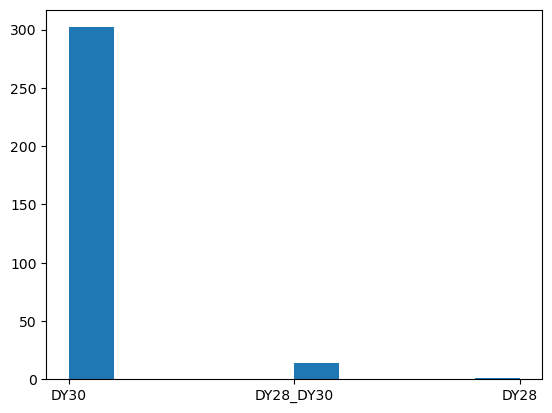

In [191]:
import matplotlib.pyplot as plt

plt.hist(major_agreed_eval_merged.DY)

(array([288., 288.,   0., 288., 288.,   0., 288., 288.,   0., 288., 288.,
          0., 288., 288., 288.]),
 array([ 0.        ,  0.66666667,  1.33333333,  2.        ,  2.66666667,
         3.33333333,  4.        ,  4.66666667,  5.33333333,  6.        ,
         6.66666667,  7.33333333,  8.        ,  8.66666667,  9.33333333,
        10.        ]),
 <BarContainer object of 15 artists>)

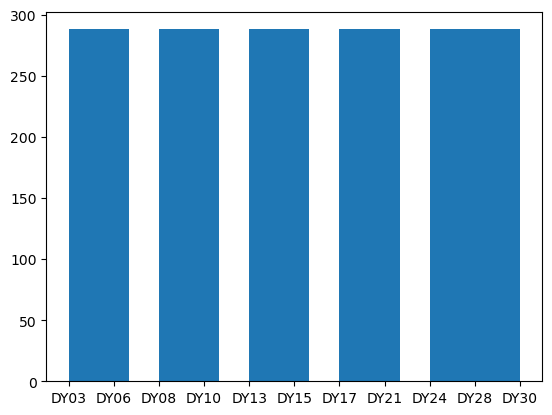

In [192]:
plt.hist(select_meta_df.DY, 15)

In [193]:
import numpy as np

np.unique(select_meta_df.DY)

array(['DY03', 'DY06', 'DY08', 'DY10', 'DY13', 'DY15', 'DY17', 'DY21',
       'DY24', 'DY28', 'DY30'], dtype=object)

In [194]:
major_agreed_eval_merged[major_agreed_eval_merged["DY"] == "DY28"]

evaluation,image_id,Acceptable,Not Acceptable,fully_agreed_consensus,majority_agreed_consensus,ID-DY,DY
225,BA4 96_1 DY28 F8,0,5,Not Acceptable,Not Acceptable,BA4 96_1 F8,DY28


In [195]:
merged = pd.merge(
    major_agreed_eval[["image_id", "majority_agreed_consensus"]],
    select_meta_df,
    left_on="image_id",
    right_on="sample_id",
    how="inner",
)

In [196]:
merged

,image_id,majority_agreed_consensus,sample_id,GlucoseGlo_concentration_uM,GlutamateGlo_concentration_uM,MalateGlo_concentration_uM,BCAAGlo_concentration_uM,LactateGlo_concentration_uM,PyruvateGlo_concentration_uM,ID-DY,DY
0,BA1 96_1 DY28 A2,Acceptable,BA1 96_1 DY28 A2,12.738,0.210,0.214,5.750,13.228,1.915,BA1 96_1 A2,DY28
1,BA1 96_1 DY28 A8,Not Acceptable,BA1 96_1 DY28 A8,11.382,0.230,0.342,5.428,21.811,1.902,BA1 96_1 A8,DY28
2,BA1 96_1 DY28 E10,Not Acceptable,BA1 96_1 DY28 E10,12.600,0.258,0.138,5.257,13.998,0.987,BA1 96_1 E10,DY28
3,BA1 96_1 DY28 F12,Acceptable,BA1 96_1 DY28 F12,12.648,0.375,0.218,5.445,21.136,2.825,BA1 96_1 F12,DY28
4,BA1 96_1 DY28 G11,Acceptable,BA1 96_1 DY28 G11,13.146,0.264,0.197,5.690,21.736,1.928,BA1 96_1 G11,DY28
...,...,...,...,...,...,...,...,...,...,...,...
183,BA2 96_2 DY30 G6,Not Acceptable,BA2 96_2 DY30 G6,11.783,0.505,-0.097,4.937,6.098,1.171,BA2 96_2 G6,DY30
184,BA2 96_2 DY30 G7,Not Acceptable,BA2 96_2 DY30 G7,9.763,0.402,-0.101,4.133,6.120,1.322,BA2 96_2 G7,DY30
185,BA2 96_2 DY30 G9,Not Acceptable,BA2 96_2 DY30 G9,12.783,0.843,-0.040,5.515,4.440,1.728,BA2 96_2 G9,DY30
186,BA2 96_2 DY30 H1,Acceptable,BA2 96_2 DY30 H1,10.659,0.093,0.039,4.940,16.296,3.429,BA2 96_2 H1,DY30


In [197]:
for days in np.unique(select_meta_df.DY):
    selected_meta_df = select_meta_df[select_meta_df["DY"] == days]
    per_day_metabolite_survey_data = pd.merge(
        survey_label_selected,
        selected_meta_df,
        left_on="ID-DY",
        right_on="ID-DY",
        how="inner",
    )
    print(
        days
        + ":+"
        + str(
            len(
                per_day_metabolite_survey_data[
                    per_day_metabolite_survey_data["majority_agreed_consensus"]
                    == "Acceptable"
                ]
            )
        )
        + ",-"
        + str(
            len(
                per_day_metabolite_survey_data[
                    per_day_metabolite_survey_data["majority_agreed_consensus"]
                    != "Acceptable"
                ]
            )
        )
    )
    # break

DY03:+151,-25
DY06:+151,-25
DY08:+151,-25
DY10:+151,-25
DY13:+151,-25
DY15:+151,-25
DY17:+151,-25
DY21:+151,-25
DY24:+151,-25
DY28:+151,-25
DY30:+151,-25


In [198]:
per_day_metabolite_survey_data.columns

Index(['ID-DY', 'majority_agreed_consensus', 'sample_id',
       'GlucoseGlo_concentration_uM', 'GlutamateGlo_concentration_uM',
       'MalateGlo_concentration_uM', 'BCAAGlo_concentration_uM',
       'LactateGlo_concentration_uM', 'PyruvateGlo_concentration_uM', 'DY'],
      dtype='object')

DY03:+151,-25
                precision    recall  f1-score   support

    Acceptable       0.91      0.61      0.73        51
Not Acceptable       0.20      0.62      0.30         8

      accuracy                           0.61        59
     macro avg       0.56      0.62      0.52        59
  weighted avg       0.82      0.61      0.67        59

Accuracy: 0.6101694915254238
Classification Report:
                 precision    recall  f1-score   support

    Acceptable       0.91      0.61      0.73        51
Not Acceptable       0.20      0.62      0.30         8

      accuracy                           0.61        59
     macro avg       0.56      0.62      0.52        59
  weighted avg       0.82      0.61      0.67        59

DY06:+151,-25
                precision    recall  f1-score   support

    Acceptable       0.94      0.67      0.78        51
Not Acceptable       0.26      0.75      0.39         8

      accuracy                           0.68        59
     macro avg 

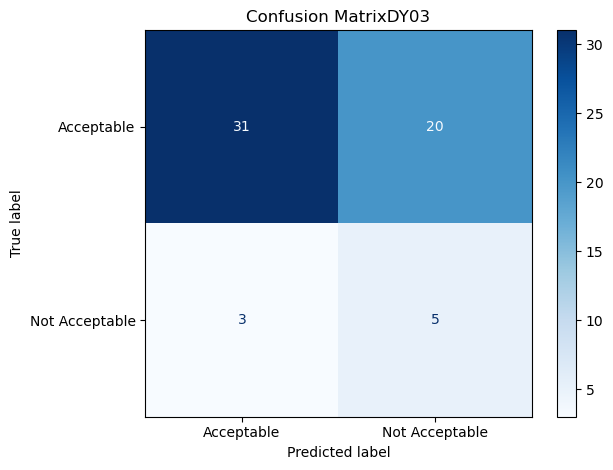

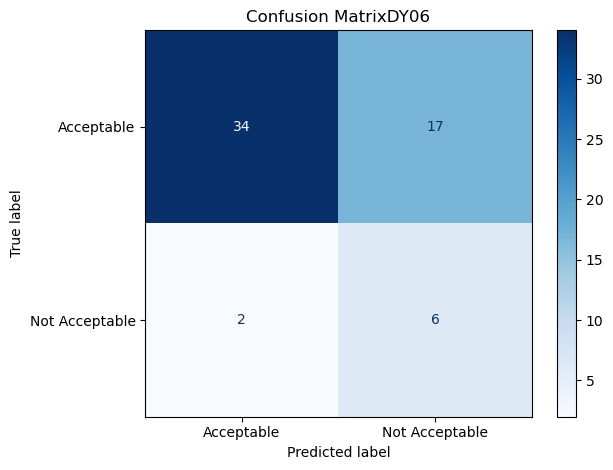

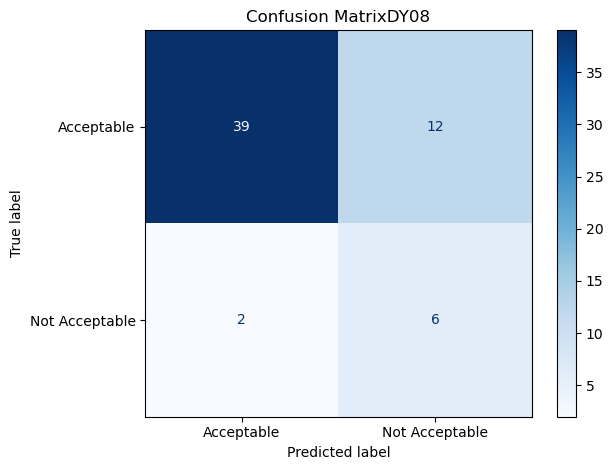

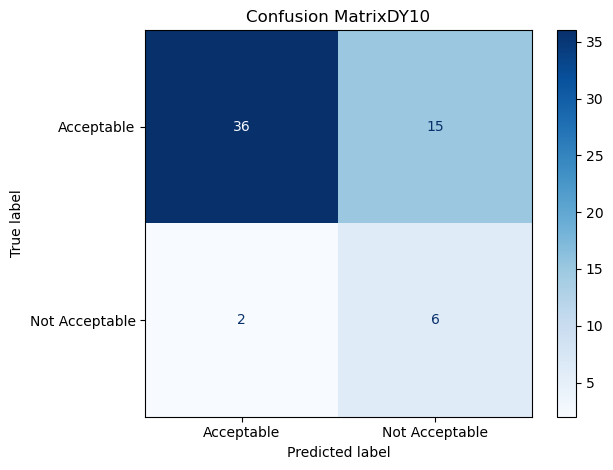

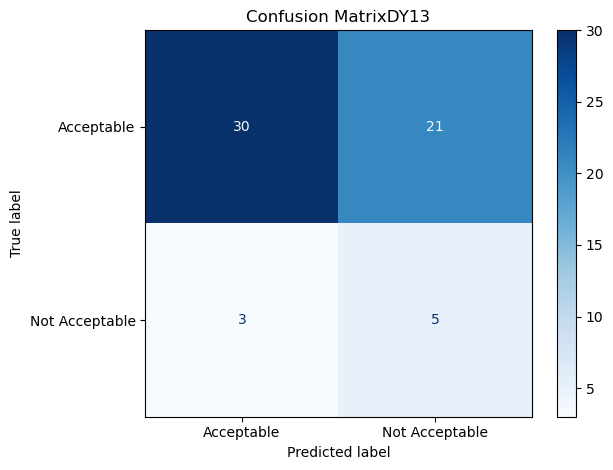

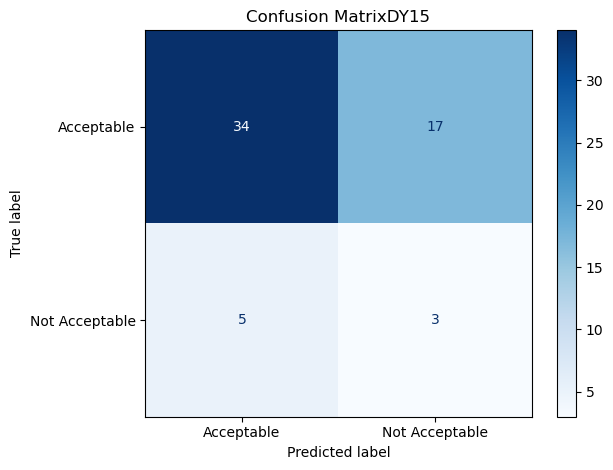

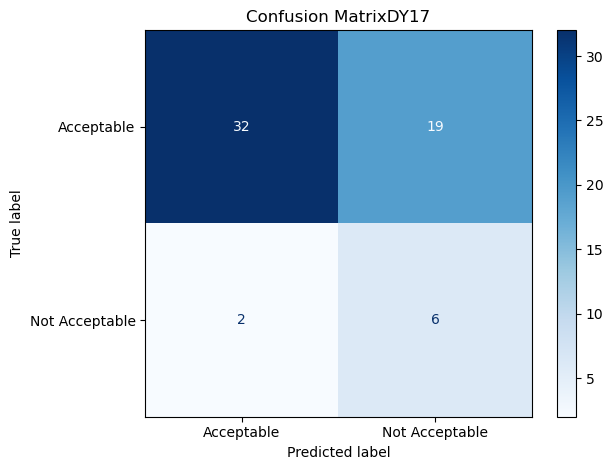

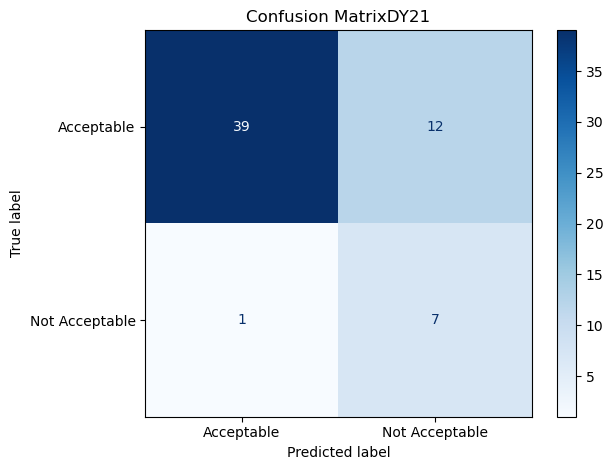

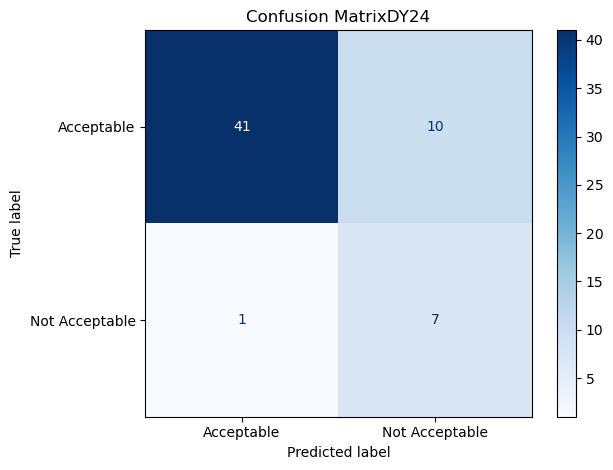

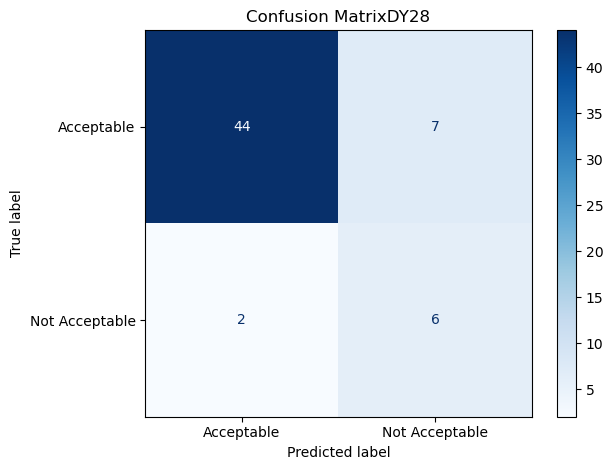

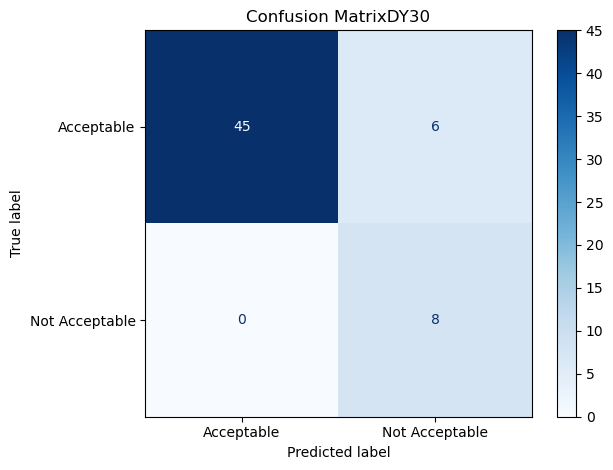

In [199]:
output_df = pd.DataFrame(
    columns={
        "DY",
        "accuracy_score_value",
        "precision_accept",
        "precision_notaccept",
        "recall_accept",
        "recall_notaccept",
        "f1-score_accept",
        "f1-score_accept",
    }
)

for days in np.unique(select_meta_df.DY):
    selected_meta_df = select_meta_df[select_meta_df["DY"] == days]
    per_day_metabolite_survey_data = pd.merge(
        survey_label_selected,
        selected_meta_df,
        left_on="ID-DY",
        right_on="ID-DY",
        how="inner",
    )
    print(
        days
        + ":+"
        + str(
            len(
                per_day_metabolite_survey_data[
                    per_day_metabolite_survey_data["majority_agreed_consensus"]
                    == "Acceptable"
                ]
            )
        )
        + ",-"
        + str(
            len(
                per_day_metabolite_survey_data[
                    per_day_metabolite_survey_data["majority_agreed_consensus"]
                    != "Acceptable"
                ]
            )
        )
    )

    data = per_day_metabolite_survey_data.drop(columns={"sample_id", "DY"})

    # Split features and labels
    X = data.drop(columns={"majority_agreed_consensus", "ID-DY"})
    y = data["majority_agreed_consensus"]
    id_col = data["ID-DY"]

    # Split into train/test

    X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
        X, y, id_col, test_size=0.33, stratify=y, random_state=42
    )

    if methodstr == "randomForrest":
        # Train the classifier
        model = RandomForestClassifier(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)

    if methodstr == "LogisticRegression":
        # Step 3: Feature scaling
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Step 4: Initialize and train the logistic regression model
        model = LogisticRegression(
            penalty="l2", C=1.0, solver="liblinear", random_state=42
        )
        model.fit(X_train_scaled, y_train)

        # Step 5: Evaluate the model
        y_pred = model.predict(X_test_scaled)

    if methodstr == "LogisticRegression_SMOTE":
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Resample

        sm = SMOTE(random_state=42)
        X_resampled, y_resampled = sm.fit_resample(X_train_scaled, y_train)

        # Train model with class weights
        model = LogisticRegression(class_weight="balanced", solver="liblinear")
        model.fit(X_resampled, y_resampled)

        # Predict and evaluate
        y_pred = model.predict(X_test_scaled)

    if methodstr == "svm":
        # ---- Step 3: Scale features ----
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # ---- Step 4: Train SVM ----
        model = SVC(
            kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42
        )
        model.fit(X_train_scaled, y_train)

        # ---- Step 5: Predict and evaluate ----
        y_pred = model.predict(X_test_scaled)

    print(classification_report(y_test, y_pred))

    # Evaluation
    accuracy_score_value = accuracy_score(y_test, y_pred)
    print("Accuracy:", accuracy_score_value)
    report = classification_report(y_test, y_pred, output_dict=True)
    print("Classification Report:\n", classification_report(y_test, y_pred))

    precision_accept = report["Acceptable"]["precision"]
    precision_notaccept = report["Not Acceptable"]["precision"]
    recall_accept = report["Acceptable"]["recall"]
    recall_notaccept = report["Not Acceptable"]["recall"]
    f1_score_accept = report["Acceptable"]["f1-score"]
    f1_score_notaccept = report["Not Acceptable"]["f1-score"]

    s = pd.Series(
        [
            days,
            accuracy_score_value,
            precision_accept,
            precision_notaccept,
            recall_accept,
            recall_notaccept,
            f1_score_accept,
            f1_score_notaccept,
        ],
        index=[
            "DY",
            "accuracy_score_value",
            "precision_accept",
            "precision_notaccept",
            "recall_accept",
            "recall_notaccept",
            "f1-score_accept",
            "f1-score_notaccept",
        ],
    )

    output_df = output_df.append(s, ignore_index=True)

    # # Feature importance
    # importances = clf.feature_importances_
    # feature_names = X.columns
    # plt.figure(figsize=(8, 5))
    # plt.bar(feature_names, importances)
    # plt.title("Feature Importances"  + days)
    # plt.xticks(rotation=45)
    # plt.xlabel("Features")
    # plt.ylabel("Importance")
    # plt.tight_layout()
    # plt.savefig(os.path.join(output_folder,'feature_'+methodstr+'_'+days+'.png'))

    # Generate confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix" + days)
    plt.tight_layout()
    plt.savefig(
        os.path.join(
            output_folder, "confusion_matrix_" + methodstr + "_" + days + ".png"
        )
    )

In [200]:
y_pred

array(['Acceptable', 'Acceptable', 'Not Acceptable', 'Acceptable',
       'Acceptable', 'Acceptable', 'Acceptable', 'Not Acceptable',
       'Not Acceptable', 'Acceptable', 'Acceptable', 'Not Acceptable',
       'Acceptable', 'Acceptable', 'Acceptable', 'Acceptable',
       'Acceptable', 'Acceptable', 'Acceptable', 'Not Acceptable',
       'Acceptable', 'Acceptable', 'Acceptable', 'Acceptable',
       'Not Acceptable', 'Acceptable', 'Not Acceptable', 'Acceptable',
       'Acceptable', 'Acceptable', 'Acceptable', 'Acceptable',
       'Not Acceptable', 'Not Acceptable', 'Acceptable', 'Acceptable',
       'Acceptable', 'Not Acceptable', 'Acceptable', 'Acceptable',
       'Acceptable', 'Acceptable', 'Acceptable', 'Acceptable',
       'Not Acceptable', 'Acceptable', 'Acceptable', 'Acceptable',
       'Acceptable', 'Acceptable', 'Not Acceptable', 'Acceptable',
       'Acceptable', 'Not Acceptable', 'Acceptable', 'Acceptable',
       'Acceptable', 'Not Acceptable', 'Acceptable'], dtype=object

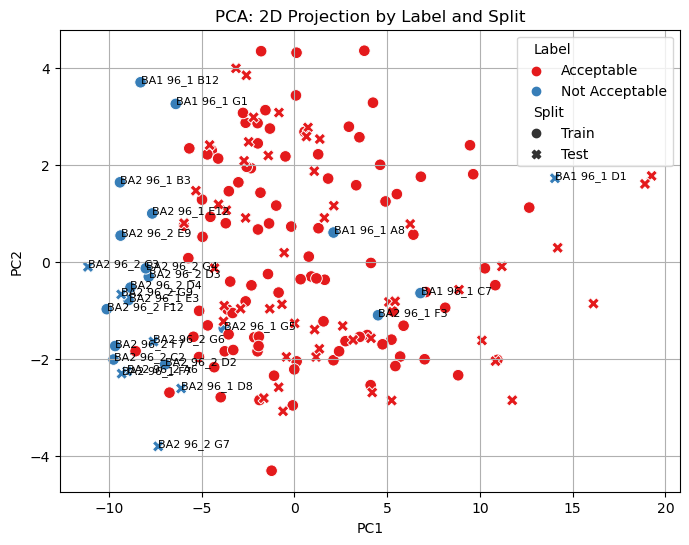

/home/ldin/anaconda3/envs/segmentation/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/home/ldin/anaconda3/envs/segmentation/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


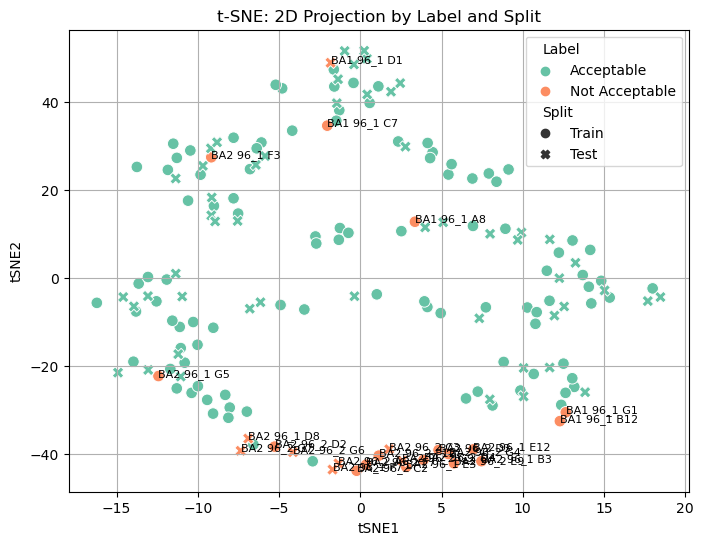

In [201]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Combine train/test sets and add labels
X_all = np.vstack([X_train, X_test])
y_all = np.concatenate([y_train, y_test])
id_all = np.concatenate([id_train, id_test])
split = np.array(["Train"] * len(X_train) + ["Test"] * len(X_test))

# Create dataframe
df = pd.DataFrame(X_all, columns=[f"Feature_{i}" for i in range(X_all.shape[1])])
df["Label"] = y_all
df["Split"] = split

# # ---------------------------
# # 1. Pairplot
# # ---------------------------
# sns.pairplot(df, hue='Label', palette='Set1', diag_kind='hist', markers=['o', 's'], corner=True, plot_kws={'alpha': 0.7})
# plt.suptitle('Pairplot of Features by Class', y=1.02)
# plt.show()

# ---------------------------
# 2. PCA Projection
# ---------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_all)
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["Label"] = y_all
df_pca["Split"] = split

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca, x="PC1", y="PC2", hue="Label", style="Split", palette="Set1", s=70
)
for x, y, id, label in zip(df_pca.PC1, df_pca.PC2, id_all, df_pca.Label):
    if label == "Not Acceptable":
        plt.text(x, y, str(id), fontsize=8)
plt.title("PCA: 2D Projection by Label and Split")
plt.grid(True)
plt.show()

# ---------------------------
# 3. t-SNE Projection
# ---------------------------
tsne = TSNE(n_components=2, perplexity=10, random_state=42)
X_tsne = tsne.fit_transform(X_all)
df_tsne = pd.DataFrame(X_tsne, columns=["tSNE1", "tSNE2"])
df_tsne["Label"] = y_all
df_tsne["Split"] = split

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_tsne, x="tSNE1", y="tSNE2", hue="Label", style="Split", palette="Set2", s=70
)
for x, y, id, label in zip(df_tsne.tSNE1, df_tsne.tSNE2, id_all, df_tsne.Label):
    if label == "Not Acceptable":
        plt.text(x, y, str(id), fontsize=8)
plt.title("t-SNE: 2D Projection by Label and Split")
plt.grid(True)
plt.show()

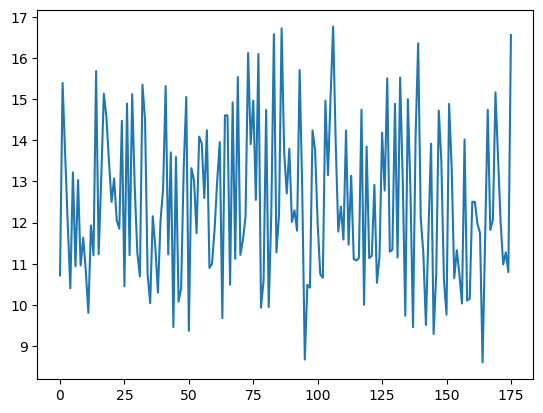

In [202]:
plt.plot(X_all[:, 0])

In [203]:
output_df

,recall_notaccept,recall_accept,accuracy_score_value,DY,precision_notaccept,precision_accept,f1-score_accept,f1-score_notaccept
0,0.625,0.607843,0.610169,DY03,0.200000,0.911765,0.729412,0.303030
1,0.750,0.666667,0.677966,DY06,0.260870,0.944444,0.781609,0.387097
2,0.750,0.764706,0.762712,DY08,0.333333,0.951220,0.847826,0.461538
3,0.750,0.705882,0.711864,DY10,0.285714,0.947368,0.808989,0.413793
4,0.625,0.588235,0.593220,DY13,0.192308,0.909091,0.714286,0.294118
5,0.375,0.666667,0.627119,DY15,0.150000,0.871795,0.755556,0.214286
6,0.750,0.627451,0.644068,DY17,0.240000,0.941176,0.752941,0.363636
7,0.875,0.764706,0.779661,DY21,0.368421,0.975000,0.857143,0.518519
8,0.875,0.803922,0.813559,DY24,0.411765,0.976190,0.881720,0.560000
9,0.750,0.862745,0.847458,DY28,0.461538,0.956522,0.907216,0.571429


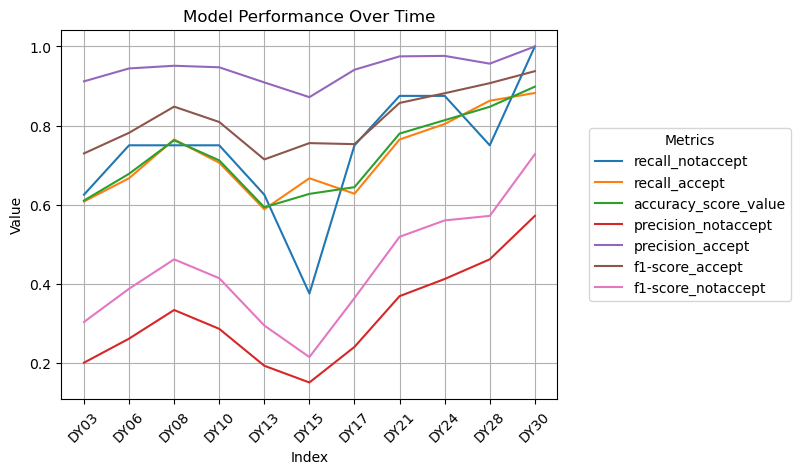

In [204]:
ax = output_df.drop(columns="DY").plot()
# Add legend
plt.legend(
    title="Metrics", loc="center left", bbox_to_anchor=(1.05, 0.5)
)  # Optional title
plt.xlabel("Index")  # Optional x-axis label
plt.ylabel("Value")  # Optional y-axis label
plt.title("Model Performance Over Time")  # Optional title

# Use custom tick positions and labels
ax.set_xticks(range(len(output_df)))
ax.set_xticklabels(output_df["DY"], rotation=45)


plt.grid(True)
plt.savefig(os.path.join(output_folder, "metrics_" + methodstr + ".png"))